In [1]:
## Reference
# https://www.coursera.org/learn/introduction-computer-vision-watson-opencv

In [2]:
import copy
import os,sys
os.chdir('/Users/levgolod/Projects/car_classifier/')
from _02_preprocess_data.preprocess_data_fns import *

/Users/levgolod/Projects/venv3/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator


import pandas as pd
# import tensorflow.compat.v1 as tf
from common_params import parent_directory_images, parent_directory_url_csvs
import importlib
import sys,os
import pandas as pd
from timethis import timethis



2025-03-03 12:31:28.966782: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
output_filename = f'{parent_directory_url_csvs}df_clip_pred_bodystyle.csv'

In [5]:
IMAGE_SIZE = 256 # increase later
SAMPLE_SIZE = 10000 # increase later

class_names_use = ['sedan','suv','truck']
label_dict = {v:k for k,v in body_style_dict.items()}
print(label_dict)
class_names = list(label_dict.values())
class_labels_use = list([v for k,v in body_style_dict.items() if k in class_names_use])
class_labels_use

{0: 'sedan', 1: 'sportscar', 2: 'suv', 3: 'truck', 4: 'van', 5: 'wagon'}


[0, 2, 3]

### Ingest image data from disk

In [ ]:
output_filename_train_val_holdout = f'{parent_directory_url_csvs}df_train_val_hold.csv'
df=pd.read_csv(output_filename_train_val_holdout).sample(frac=1)
df=df.loc[df['body_style'].isin(class_names_use), ].reset_index()
print(df.shape)
print(df.partition.value_counts(dropna=False,normalize=True))
df.head()

In [ ]:
if False:

    train_dataset = process_image_files(
        df.loc[df['partition']=='train', ['filepath_to_use','body_style_index']].head(SAMPLE_SIZE).values,
        image_size=IMAGE_SIZE,
    )

    test_dataset = process_image_files(
        df.loc[df['partition']=='val', ['filepath_to_use','body_style_index']].head(SAMPLE_SIZE).values,
        image_size=IMAGE_SIZE,
    )

    holdout_dataset = process_image_files(
        df.loc[df['partition']=='hold', ['filepath_to_use','body_style_index']].head(SAMPLE_SIZE).values,
        image_size=IMAGE_SIZE,
    )

    print(len(train_dataset),len(test_dataset),len(holdout_dataset))
    train_images, train_labels = \
    ptrain_images, train_labels = \
        [x[0] for x in train_dataset], [x[1] for x in train_dataset]

    test_images, test_labels = \
        [x[0] for x in test_dataset], [x[1] for x in test_dataset]

    holdout_images, holdout_labels = \
        [x[0] for x in holdout_dataset], [x[1] for x in holdout_dataset]

    ## coerce to array - data
    train_images = np.array([np.array(x) for x in train_images])
    test_images = np.array([np.array(x) for x in test_images])
    holdout_images = np.array([np.array(x) for x in holdout_images])

    ## coerce to array - labels
    train_labels = np.array(train_labels)
    test_labels = np.array(test_labels)
    holdout_labels = np.array(holdout_labels)

In [ ]:
class_names_use
i=0
record=dict(df.loc[i, ])
record

probs = get_predicted_categories_clip(
            image_path= record['filepath'],
            categories=class_names_use
        )
probs

top_category  = probs.head(1).index[0]
probs_dict = dict(probs)
top_category, probs_dict

In [ ]:
df['clip_probs']=''
df['clip_prediction']=''

iterprint = 100
for i,record in df.iterrows():
    if i % iterprint==0:
        message =\
f'''###########################################################
### Begin processing {i} of {len(df)} | {dt.datetime.now().replace(microsecond=0)}
###########################################################'''
        print(message) # second

    image_path= record['filepath']
    try:
        probs = get_predicted_categories_clip(
                image_path,
                categories=class_names_use
            )
        top_category  = probs.head(1).index[0]
        probs_dict = dict(probs)
        df.loc[i, 'clip_probs'] = str(probs_dict)
        df.loc[i, 'clip_prediction'] = str(top_category)
    except Exception as e:
        print(f'\nProblem with {i} {image_path}')
        print(e)





In [ ]:
df.head()



In [ ]:
df.to_csv(output_filename,index=False)

In [6]:
df = pd.read_csv(output_filename)

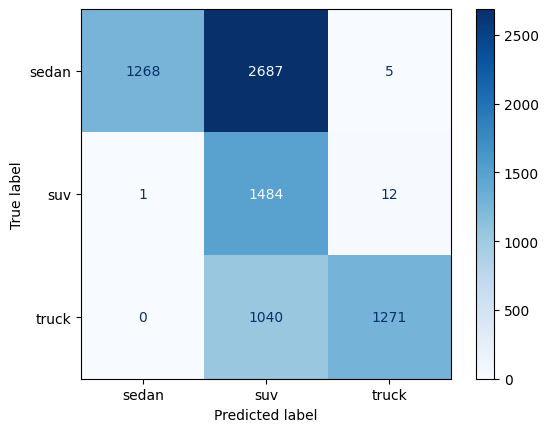

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm =confusion_matrix(df['body_style'], df['clip_prediction'], labels=class_names_use)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names_use)
disp.plot(cmap='Blues')
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

def custom_classification_report(true_labels, predicted_labels, class_names):
    """
    Generates a classification report similar to the Terraform style with precision, recall, f1-score, and support.

    Args:
    true_labels (list): List of true labels.
    predicted_labels (list): List of predicted labels.
    class_names (list): List of class names to show in the report.

    Returns:
    str: Formatted classification report.
    """
    # Get precision, recall, f1-score, and support for each class
    precision, recall, f1, support = precision_recall_fscore_support(true_labels, predicted_labels, labels=class_names, average=None)

    # Create a pandas DataFrame for clean formatting
    report_df = pd.DataFrame({
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'support': support
    }, index=class_names)

    # Format the DataFrame to match the Terraform report style
    report_str = report_df.to_string(formatters={
        'precision': '{:0.2f}'.format,
        'recall': '{:0.2f}'.format,
        'f1-score': '{:0.2f}'.format,
        'support': '{:0.0f}'.format
    })

    return report_df, report_str


In [ ]:
_,report_str= custom_classification_report(df['body_style'], df['clip_prediction'], class_names=class_names_use)
print(report_str)

In [8]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd

def custom_classification_report(true_labels, predicted_labels, class_names):
    '''

              precision    recall  f1-score   support

       sedan       0.71      0.70      0.71       499
         suv       0.49      0.26      0.34       210
       truck       0.51      0.67      0.58       328

    accuracy                           0.60      1037
   macro avg       0.57      0.54      0.54      1037
weighted avg       0.60      0.60      0.59      1037
    '''

  # Get precision, recall, f1-score, and support for each class
    precision, recall, f1, support = precision_recall_fscore_support(true_labels, predicted_labels, labels=class_names, average=None)

    # Compute overall accuracy
    accuracy = accuracy_score(true_labels, predicted_labels)

    # Compute macro and weighted averages
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1)

    weighted_precision = np.average(precision, weights=support)
    weighted_recall = np.average(recall, weights=support)
    weighted_f1 = np.average(f1, weights=support)

    # Create a pandas DataFrame for clean formatting
    report_df = pd.DataFrame({
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'support': support
    }, index=class_names)

    # Add the averages and accuracy to the report
    avg_stats = pd.DataFrame({
        'precision': [macro_precision, weighted_precision],
        'recall': [macro_recall, weighted_recall],
        'f1-score': [macro_f1, weighted_f1],
        'support': [np.sum(support), np.sum(support)]  # Total support for both avg rows
    }, index=['macro avg', 'weighted avg'])

    # Add the accuracy row
    accuracy_row = pd.DataFrame({
        'precision': [''],
        'recall': [''],
        'f1-score': [accuracy],
        'support': [len(true_labels)]
    }, index=['accuracy'])

    # Combine the individual class report, accuracy, and average rows
    report_df = pd.concat([report_df, accuracy_row, avg_stats])

    # Format the DataFrame to match the Terraform report style
    report_str = report_df.to_string(formatters={
        'precision': '{:0.2f}'.format,
        'recall': '{:0.2f}'.format,
        'f1-score': '{:0.2f}'.format,
        'support': '{:0.0f}'.format
    })
    report_str=report_str.replace('NaN','   ')
    return report_df, report_str

In [13]:
_,report_str= custom_classification_report(df['body_style'], df['clip_prediction'], class_names=class_names_use)
print(report_str.replace('NaN','   '))

             precision recall f1-score support
sedan             1.00   0.32     0.48    3960
suv               0.28   0.99     0.44    1497
truck             0.99   0.55     0.71    2311
accuracy                          0.52    7768
macro avg         0.76   0.62     0.54    7768
weighted avg      0.86   0.52     0.54    7768


In [15]:
df_test = df.loc[df['partition']=='val', ]
df_test.shape
_,report_str= custom_classification_report(df_test['body_style'], df_test['clip_prediction'], class_names=class_names_use)
print(report_str.replace('NaN','   '))

             precision recall f1-score support
sedan             1.00   0.30     0.46     499
suv               0.29   0.99     0.45     210
truck             0.98   0.52     0.68     328
accuracy                          0.51    1037
macro avg         0.76   0.60     0.53    1037
weighted avg      0.85   0.51     0.53    1037
